In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load processed data
df = pd.read_csv('../data/train_processed.csv', parse_dates=['date'])
print(f"Shape: {df.shape}")
print("Data loaded.")

Shape: (2950992, 33)
Data loaded.


Additinal features


In [3]:
# Sort for correct lag calculations
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# --- Promotion lag features ---
# Was this item on promotion last week?
df['promo_lag_7'] = df.groupby(['store_nbr', 'family'])['onpromotion'].shift(7)
# Rolling promotion count over last 14 days
df['promo_rolling_14'] = df.groupby(['store_nbr', 'family'])['onpromotion'].transform(
    lambda x: x.shift(1).rolling(window=14, min_periods=1).sum()
)

# --- Sales volatility ---
# How unpredictable are sales? (rolling standard deviation)
df['rolling_7_std'] = df.groupby(['store_nbr', 'family'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).std()
)

# --- Ratio features ---
# How does today's lag compare to the rolling average? (captures momentum)
df['lag7_to_rolling7_ratio'] = df['lag_7'] / (df['rolling_7_mean'] + 1)

# --- Time distance features ---
# Day of year (captures annual position: 1-365)
df['day_of_year'] = df['date'].dt.dayofyear

# Days until end of month (spending behavior)
df['days_to_month_end'] = (df['date'].dt.days_in_month - df['day_of_month'])

# Is it December? (strongest seasonal effect we saw)
df['is_december'] = (df['month'] == 12).astype(int)

# --- Weekend + Promotion interaction ---
df['weekend_x_promo'] = df['is_weekend'] * df['onpromotion']

print("New features added:")
new_features = ['promo_lag_7', 'promo_rolling_14', 'rolling_7_std', 
                'lag7_to_rolling7_ratio', 'day_of_year', 'days_to_month_end',
                'is_december', 'weekend_x_promo']
for f in new_features:
    print(f"  {f}: NaN count = {df[f].isna().sum():,}")

print(f"\nShape: {df.shape}")

New features added:
  promo_lag_7: NaN count = 12,474
  promo_rolling_14: NaN count = 1,782
  rolling_7_std: NaN count = 3,564
  lag7_to_rolling7_ratio: NaN count = 0
  day_of_year: NaN count = 0
  days_to_month_end: NaN count = 0
  is_december: NaN count = 0
  weekend_x_promo: NaN count = 0

Shape: (2950992, 41)


TARGET TRANSFORMATION + TRAIN/TEST SPLIT

In [5]:
# Droping rows with NaN in new features
df_clean = df.dropna(subset=['promo_lag_7', 'rolling_7_std']).reset_index(drop=True)

# Time-based split (same cutoff as before)
split_date = '2017-07-16'
train_data = df_clean[df_clean['date'] < split_date]
test_data = df_clean[df_clean['date'] >= split_date]

feature_columns_v2 = [
    # Original features
    'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year',
    'is_weekend', 'is_payday', 'is_month_start',
    'store_nbr', 'cluster', 'type_encoded', 'city_encoded', 'state_encoded',
    'family_encoded', 'onpromotion', 'dcoilwtico',
    'is_national_holiday', 'is_regional_holiday', 'is_transferred_holiday', 'is_holiday',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_7_mean', 'rolling_14_mean', 'rolling_28_mean',
    # New features
    'promo_lag_7', 'promo_rolling_14', 'rolling_7_std',
    'lag7_to_rolling7_ratio', 'day_of_year', 'days_to_month_end',
    'is_december', 'weekend_x_promo'
]

X_train = train_data[feature_columns_v2]
X_test = test_data[feature_columns_v2]

# Log transform the target (handles skewness)
y_train_log = np.log1p(train_data['sales'])  # log(1 + sales) to handle zeros
y_test_actual = test_data['sales'].values
print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Features:     {len(feature_columns_v2)}")
print(f"\nTarget transformation: log(1 + sales)")
print(f"  Before - mean: {train_data['sales'].mean():.2f}, std: {train_data['sales'].std():.2f}")
print(f"  After  - mean: {y_train_log.mean():.2f}, std: {y_train_log.std():.2f}")

Training set: 2,883,276 rows
Test set:     55,242 rows
Features:     34

Target transformation: log(1 + sales)
  Before - mean: 359.14, std: 1105.54
  After  - mean: 2.93, std: 2.70


HYPERPARAMETER TUNING WITH CROSS-VALIDATION

In [6]:

from sklearn.model_selection import TimeSeriesSplit

# We'll test a few configurations manually (grid search on 3M rows is too slow)
configs = [
    {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 10},
    {'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.02, 'subsample': 0.85, 'colsample_bytree': 0.8, 'min_child_weight': 5},
    {'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.05, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 8},
]

print("Testing 3 configurations...\n")
best_mae = float('inf')
best_config = None
best_model = None

for i, config in enumerate(configs):
    print(f"Config {i+1}: depth={config['max_depth']}, lr={config['learning_rate']}, trees={config['n_estimators']}")
    
    model = XGBRegressor(
        **config,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    # Train on log-transformed target
    model.fit(X_train, y_train_log)
    
    # Predict and inverse transform
    preds_log = model.predict(X_test)
    preds = np.expm1(preds_log)  # inverse of log1p
    preds = np.clip(preds, 0, None)
    
    mae = mean_absolute_error(y_test_actual, preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
    
    mask = y_test_actual > 0
    mape = np.mean(np.abs((y_test_actual[mask] - preds[mask]) / y_test_actual[mask])) * 100
    
    print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%\n")
    
    if mae < best_mae:
        best_mae = mae
        best_config = config
        best_model = model
        best_predictions = preds

print(f"{'='*50}")
print(f"Best config: depth={best_config['max_depth']}, lr={best_config['learning_rate']}, trees={best_config['n_estimators']}")
print(f"Best MAE: {best_mae:.2f}")

Testing 3 configurations...

Config 1: depth=6, lr=0.03, trees=800
  MAE: 57.98 | RMSE: 209.05 | MAPE: 31.63%

Config 2: depth=8, lr=0.02, trees=1000
  MAE: 55.34 | RMSE: 199.79 | MAPE: 31.21%

Config 3: depth=10, lr=0.05, trees=600
  MAE: 55.06 | RMSE: 199.36 | MAPE: 31.05%

Best config: depth=10, lr=0.05, trees=600
Best MAE: 55.06


SAVE OPTIMIZED MODEL & FINAL COMPARISON


Optimized model saved!



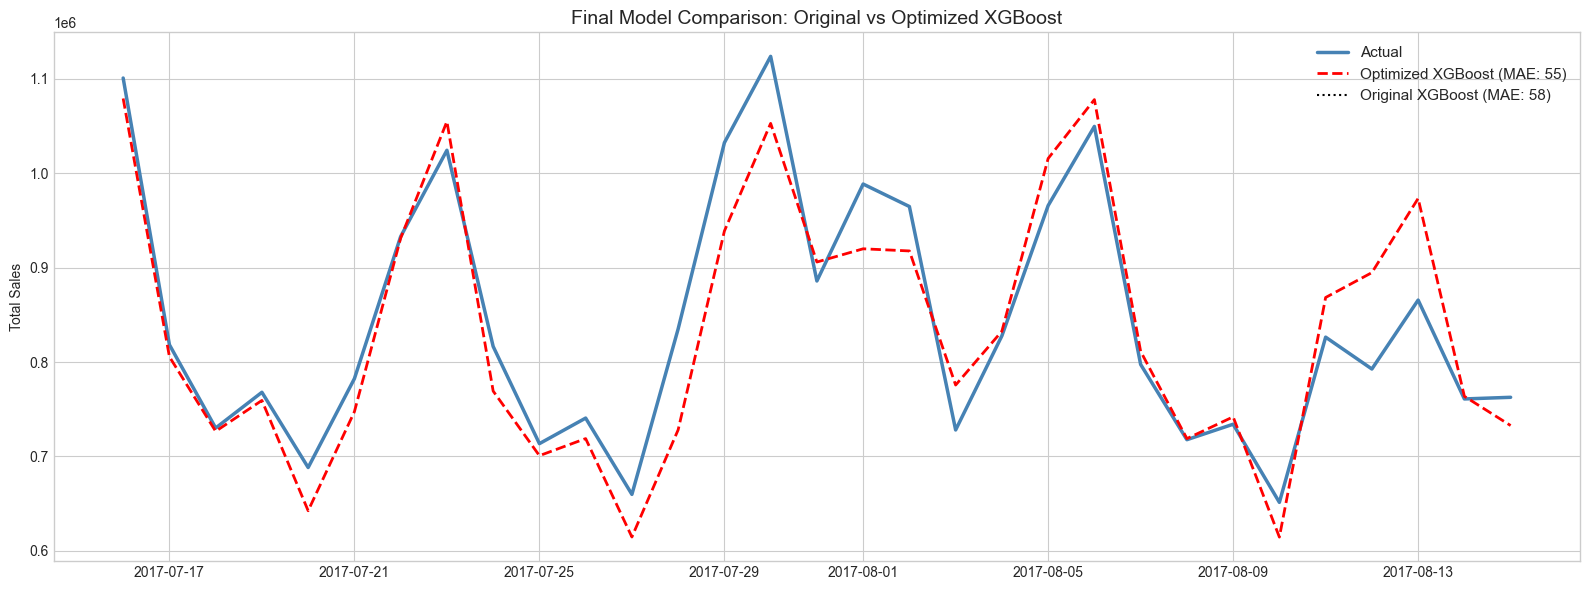


Final Results:
  Baseline MAE:           84.63
  Original XGBoost MAE:   57.79
  Optimized XGBoost MAE:  55.06
  Total improvement:      34.9% over baseline


In [9]:

# Save the best model
with open('../models/xgb_demand_model_v2.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save updated feature list
with open('../models/feature_columns_v2.pkl', 'wb') as f:
    pickle.dump(feature_columns_v2, f)

print("Optimized model saved!\n")

# Visualize final comparison
test_comp = test_data[['date']].copy()
test_comp['actual'] = y_test_actual
test_comp['predicted'] = best_predictions

daily_comp = test_comp.groupby('date').agg(
    actual=('actual', 'sum'),
    predicted=('predicted', 'sum')
).reset_index()

# Load original XGBoost predictions for comparison
original_preds = np.clip(
    np.expm1(XGBRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X_train, train_data['sales']).predict(X_test)), 0, None)

orig_daily = test_data[['date']].copy()
orig_daily['predicted'] = original_preds
orig_daily = orig_daily.groupby('date')['predicted'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_comp['date'], daily_comp['actual'], 
        label='Actual', linewidth=2.5, color='steelblue')
ax.plot(daily_comp['date'], daily_comp['predicted'], 
        label=f'Optimized XGBoost (MAE: {best_mae:.0f})', linewidth=2, color='red', linestyle='--')
ax.plot(orig_daily['date'], orig_daily['predicted'], 
        label='Original XGBoost (MAE: 58)', linewidth=1.5, color='black', linestyle=':')

ax.set_title('Final Model Comparison: Original vs Optimized XGBoost', fontsize=14)
ax.set_ylabel('Total Sales')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Baseline MAE:           84.63")
print(f"  Original XGBoost MAE:   57.79")
print(f"  Optimized XGBoost MAE:  {best_mae:.2f}")
print(f"  Total improvement:      {((84.63 - best_mae) / 84.63) * 100:.1f}% over baseline")

Phase 4: FastAPI backend. This is where we turn your trained model into a live API that accepts a store number, product family, and date, and returns a demand forecast.